# 4DFlowNet: Architecture Sweep with Mathematical Interpolation Baselines

This notebook demonstrates the reproduction of the **4DFlowNet** architecture using a physically realistic k-space MRI acquisition simulation, compared against traditional mathematical interpolation baselines (**Trilinear**, **Tricubic**, and **Sinc**).

#### The Research Context:
In the original 4DFlowNet paper (Ferdian et al.), the authors attempted to use **PixelShuffle (sub-pixel convolution)** for 3D super-resolution but rejected it because it caused severe checkerboard artifacts and poor convergence in 3D velocity space. As a result, they settled for a fixed **trilinear resize layer** inside the network, followed by residual refinement convolutions.

#### The Upgrade:
We implement the 3D sub-pixel convolution (`PixelShuffle3d`), which the paper abandoned due to convergence issues, by using modern deep learning optimization practices:
- **AdamW** optimizer for stable weight regularization.
- **Cosine Annealing** learning rate scheduler to resolve high-frequency details.
- **Gradient Clipping** (`max_norm=1.0`) to suppress the gradient explosions that trigger checkerboard instabilities.

## 0. Colab Setup

Set your runtime to **GPU** (Runtime -> Change runtime type -> GPU). If running in Colab, clone the repository and install requirements.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/eliasubz/4D-FlowNet.git
    %cd 4D-FlowNet
    !pip install -q -r requirements.txt
else:
    print("Running locally. Directory content:")
    !pwd

Running locally. Directory content:


Der Befehl "pwd" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


## 1. Imports and Config

In [2]:
import math
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.fft
from torch.utils.data import DataLoader
import scipy.ndimage
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

from src.dataset import SyntheticFlowDataset, upsample_lr
from src.model import FourDFlowNet, init_icnr_3d
from src.losses import four_d_flow_loss
from src.metrics import endpoint_error, peak_velocity_error, flow_rate_error, divergence_l1, divergence
from src.visualize import make_interactive_3d_flow_figure

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

OUTPUT_DIR = Path("outputs/colab_ablation")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
FIGURE_DIR = OUTPUT_DIR / "figures"
for path in (CHECKPOINT_DIR, PREDICTION_DIR, FIGURE_DIR):
    path.mkdir(parents=True, exist_ok=True)

# Set seeds for reproducible single-seed runs.
# We are intentionally not doing the multi-seed study yet.
torch.manual_seed(42)
np.random.seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)


Using device: cpu


## 2. Preview K-Space MRI Downsampling & 3D Geometry

Verify the physics-based k-space simulation. The pipeline applies VENC phase encoding, transforms to frequency domain (FFT), center-crops the k-space (downsampling), injects complex Gaussian noise, and returns magnitude and phase components.

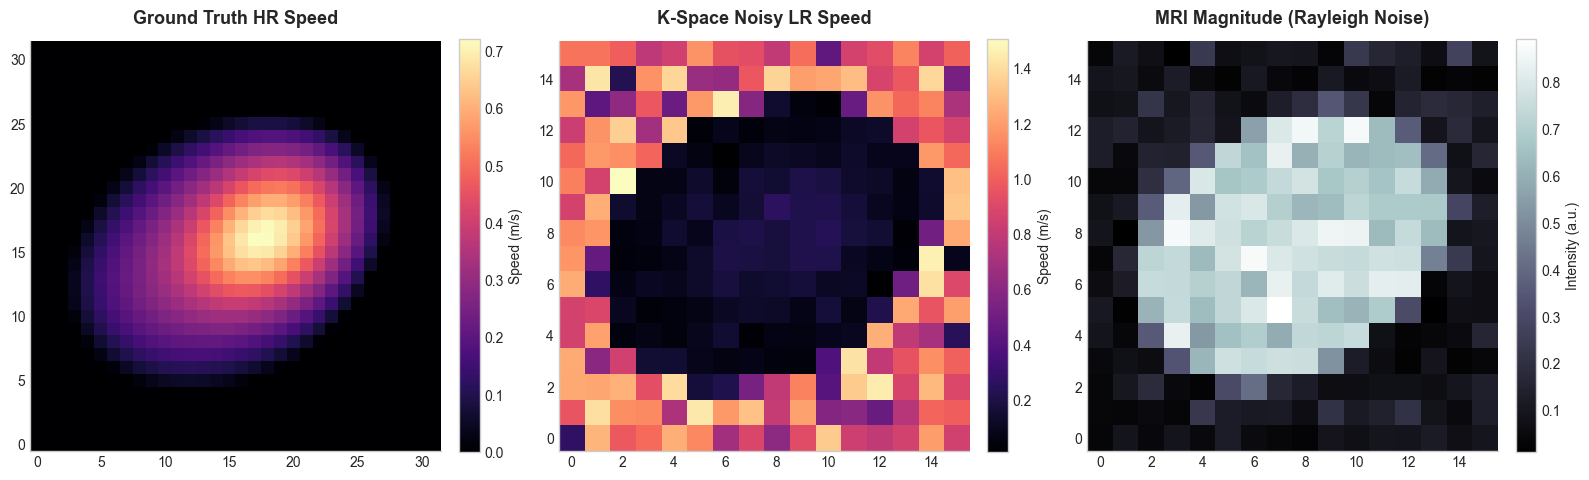

In [3]:
dataset = SyntheticFlowDataset(
    samples=1,
    use_kspace_noise=True,
    snr_range=(15.0, 15.0),
    seed=45,
    return_mask=True,
)

lr_input, hr, mask = dataset[0]

hr_speed = torch.linalg.vector_norm(hr, dim=0)
lr_speed = torch.linalg.vector_norm(lr_input[:3], dim=0)

z_lr = lr_input.shape[1] // 2
z_hr = hr.shape[1] // 2

# Create a beautiful, publication-ready grid
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=100)

# Apply a professional colormap ('magma' for speed, 'bone' for MRI magnitude)
im0 = axes[0].imshow(hr_speed[z_hr].cpu().numpy(), cmap='magma', origin='lower')
axes[0].set_title("Ground Truth HR Speed", fontsize=13, fontweight='semibold', pad=12)
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label("Speed (m/s)", fontsize=10)

im1 = axes[1].imshow(lr_speed[z_lr].cpu().numpy(), cmap='magma', origin='lower')
axes[1].set_title("K-Space Noisy LR Speed", fontsize=13, fontweight='semibold', pad=12)
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label("Speed (m/s)", fontsize=10)

im2 = axes[2].imshow(lr_input[3, z_lr].cpu().numpy(), cmap='bone', origin='lower')
axes[2].set_title("MRI Magnitude (Rayleigh Noise)", fontsize=13, fontweight='semibold', pad=12)
axes[2].grid(False)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04).set_label("Intensity (a.u.)", fontsize=10)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Interactive 3D Ground Truth Flow Field

Let's visualize the ground-truth high-resolution 3D velocity vectors and translucent vessel boundaries using Plotly. This illustrates the target fluid domain before it is degraded by low-resolution MRI physics.

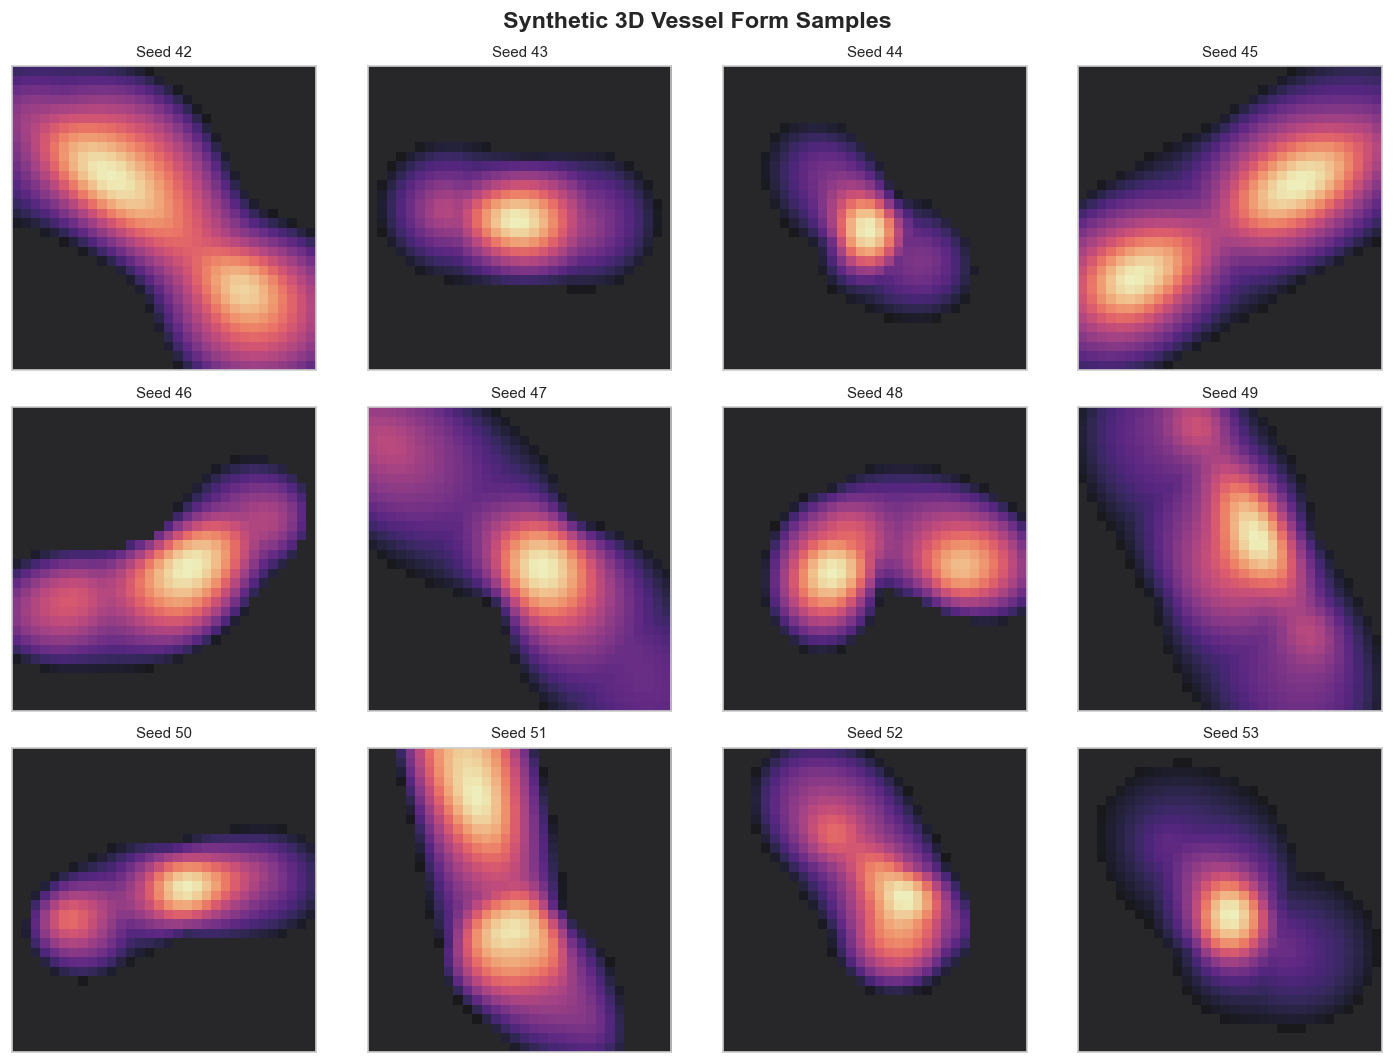

In [5]:
import torch
import matplotlib.pyplot as plt

from src.synthetic_flows import random_flow_field

n_samples = 12
size = 32
base_seed = 42

cols = 4
rows = (n_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.0, rows * 3.0), dpi=120)
axes = axes.ravel()

for i in range(n_samples):
    torch.manual_seed(base_seed + i)

    velocity, mask = random_flow_field(
        size=size,
        return_mask=True,
    )

    speed = torch.linalg.vector_norm(velocity, dim=0)

    # Project the 3D vessel into 2D. This shows the full 3D form, not one slice.
    vessel_projection = mask.max(dim=0).values
    speed_projection = speed.max(dim=0).values

    axes[i].imshow(
        vessel_projection.detach().cpu().tolist(),
        cmap="Greys",
        origin="lower",
        alpha=0.35,
    )

    axes[i].imshow(
        speed_projection.detach().cpu().tolist(),
        cmap="magma",
        origin="lower",
        alpha=0.85,
    )

    axes[i].set_title(f"Seed {base_seed + i}", fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

for ax in axes[n_samples:]:
    ax.axis("off")

fig.suptitle("Synthetic 3D Vessel Form Samples", fontsize=14, fontweight="semibold")
fig.tight_layout()
plt.show()

In [30]:

velocity, mask = random_flow_field(
    size=size,
    return_mask=True,
)
fig_gt = make_interactive_3d_flow_figure(
    velocity=velocity,
    vessel_mask=mask,
    wall_threshold=0.00,
    vector_threshold=0.10,
    vector_step=3,
    arrow_scale=0.5,
)
fig_gt.show()

## 3. Define Train & Evaluation Loop

The evaluation loop tracks the model and the three mathematical upsampling baselines (Trilinear, Tricubic, and Sinc) on identical validation batches. It computes the paper-style quantities (MAE/EPE, peak velocity error, net flow-rate error, and divergence L1), plus a **3D checkerboard index** that specifically tests the factor-2 parity artifact PixelShuffle can introduce. Training now saves configs, best/last weights, histories, and fixed validation predictions so visual artifact checks are reproducible.

For the PixelShuffle model, `FourDFlowNet` applies **ICNR 3D initialization** to the pre-shuffle convolution. This initializes each factor-2 sub-voxel branch with identical kernels at startup, which is the standard defense against checkerboard artifacts before training begins.


In [ ]:
def train_model(upsample_mode, epochs=15, train_samples=1024, val_samples=128, icnr=False):
    train_dataset = SyntheticFlowDataset(train_samples, seed=10, use_kspace_noise=True, snr_range=(14.0, 17.0))
    val_dataset = SyntheticFlowDataset(val_samples, seed=10000, use_kspace_noise=True, snr_range=(14.0, 17.0))

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    run_name = f"{upsample_mode}_icnr" if icnr else f"{upsample_mode}_no_icnr"
    checkpoint_path = CHECKPOINT_DIR / f'{run_name}_last.pt'

    start_epoch = 1
    history = []
    best_val_mae = float('inf')

    model = FourDFlowNet(
        width=24,
        lr_blocks=4,
        hr_blocks=2,
        upsample_mode=upsample_mode,
        use_icnr=icnr,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

    if checkpoint_path.exists():
        print(f"Resuming {run_name} from checkpoint {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        scheduler.T_max = epochs
        start_epoch = checkpoint['epoch'] + 1
        history = checkpoint['history']
        if history:
            best_val_mae = min(h['mae'] for h in history)
            print(f"Loaded history with {len(history)} epochs. Best Val MAE so far: {best_val_mae:.5f}")

    # If start_epoch is past the requested epochs, we don't need to train
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        running_loss = 0.0

        for lr, hr in train_loader:
            lr, hr = lr.to(device), hr.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=device.type == 'cuda'):
                pred = model(lr)
                loss = four_d_flow_loss(pred, hr, gradient_weight=1e-3)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        val_metrics, val_stds = evaluate_all(model, val_loader)
        val_metrics['train_loss'] = epoch_loss
        val_metrics['epoch'] = epoch
        val_metrics['upsample_mode'] = upsample_mode
        val_metrics['icnr'] = icnr

        for k, v in val_stds.items():
            val_metrics[f'{k}_std'] = v

        history.append(val_metrics)

        is_best = val_metrics['mae'] < best_val_mae
        if is_best:
            best_val_mae = val_metrics['mae']
            print(f"New best model found at epoch {epoch}! Val MAE: {best_val_mae:.5f}")

        # Save checkpoint
        save_checkpoint(
            run_name=run_name,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            history=history,
            metrics=val_metrics,
            is_best=is_best
        )

        if epoch % 5 == 0 or epoch == epochs:
            print(
                f"{upsample_mode} icnr={icnr} | "
                f"Epoch {epoch}/{epochs} | "
                f"Loss: {epoch_loss:.5f} | "
                f"Val MAE: {val_metrics['mae']:.5f} | "
                f"Peak Err: {100 * val_metrics['peak']:.1f}% | "
                f"Div L1: {val_metrics['div']:.5f}"
            )

    # Load best model for return
    best_path = CHECKPOINT_DIR / f'{run_name}_best.pt'
    if best_path.exists():
        print(f"Loading best model from {best_path} for returning...")
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint['history']

    return history, model

## 4. Ablation Sweep

We start out with the paper model, add pixel shuffle upsampling and then the correct initialization method (ICNR).

In [ ]:
print("Training Paper Baseline: Trilinear Resize Layer...")
trilinear_history, trilinear_model = train_model(
    "trilinear",
    epochs=15,
    icnr=False,
)

print("\nTraining PixelShuffle without ICNR...")
subpixel_no_icnr_history, subpixel_no_icnr_model = train_model(
    "subpixel",
    epochs=15,
    icnr=False,
)

print("\nTraining PixelShuffle with ICNR...")
subpixel_icnr_history, subpixel_icnr_model = train_model(
    "subpixel",
    epochs=15,
    icnr=True,
)

Training Paper Baseline: Trilinear Resize Layer...


KeyboardInterrupt: 

## 5. Quantitative Results & Comparison

Compare the model outputs alongside all three mathematical interpolation baselines across the medical metrics and the checkerboard artifact metric. This is still a **single-seed** experiment; the later defensible version should repeat this table over multiple seeds.


In [ ]:
t_final = trilinear_history[-1]
p_final = subpixel_no_icnr_history[-1]
i_final = subpixel_icnr_history[-1]


def metric_row(name, metrics, prefix=""):
    return {
        "Upsampling Method": name,
        "Val MAE": f"{metrics[f'{prefix}mae']:.5f} +/- {metrics[f'{prefix}mae_std']:.5f}",
        "EPE (Endpoint Err)": f"{metrics[f'{prefix}epe']:.5f} +/- {metrics[f'{prefix}epe_std']:.5f}",
        "Peak Velocity Err%": f"{100 * metrics[f'{prefix}peak']:.2f}% +/- {100 * metrics[f'{prefix}peak_std']:.2f}%",
        "Net Flow Err%": f"{100 * metrics[f'{prefix}flow']:.2f}% +/- {100 * metrics[f'{prefix}flow_std']:.2f}%",
        "Divergence L1": f"{metrics[f'{prefix}div']:.5f} +/- {metrics[f'{prefix}div_std']:.5f}",
        "Checkerboard Index": f"{metrics[f'{prefix}checker']:.4f} +/- {metrics[f'{prefix}checker_std']:.4f}",
    }


summary = [
    metric_row("Trilinear Interpolation", t_final, "tri_"),
    metric_row("Trilinear 4DFlowNet", t_final),
    metric_row("PixelShuffle 4DFlowNet", p_final),
    metric_row("PixelShuffle+ICNR 4DFlowNet", i_final),
]

df = pd.DataFrame(summary)
df.to_csv(OUTPUT_DIR / "ablation_metric_summary.csv", index=False)

print("\n=== Final Validation Performance Matrix (single seed, mean +/- batch std) ===")
print(df.to_markdown(index=False))
print(f"\nSaved summary to: {OUTPUT_DIR / 'ablation_metric_summary.csv'}")


plt.figure(figsize=(11, 6), dpi=120)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

epochs = np.array(range(1, len(trilinear_history) + 1))

curves = [
    ("Trilinear 4DFlowNet", trilinear_history, "#2B5C8F", "o"),
    ("PixelShuffle 4DFlowNet", subpixel_no_icnr_history, "#D95D39", "s"),
    ("PixelShuffle+ICNR 4DFlowNet", subpixel_icnr_history, "#2A9D8F", "^"),
]

for label, history, color, marker in curves:
    mae = np.array([h["mae"] for h in history])
    mae_std = np.array([h["mae_std"] for h in history])

    plt.plot(
        epochs,
        mae,
        label=label,
        color=color,
        linewidth=2.5,
        marker=marker,
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.2,
    )
    plt.fill_between(
        epochs,
        mae - mae_std,
        mae + mae_std,
        color=color,
        alpha=0.12,
    )

tri_base = t_final["tri_mae"]
tri_base_std = t_final["tri_mae_std"]

plt.axhline(
    y=tri_base,
    color="#7F8C8D",
    linestyle="--",
    linewidth=1.7,
    label="Trilinear Interpolation",
)
plt.fill_between(
    epochs,
    tri_base - tri_base_std,
    tri_base + tri_base_std,
    color="#7F8C8D",
    alpha=0.08,
)

plt.title(
    "Ablation: Trilinear vs PixelShuffle Upsampling",
    fontsize=14,
    fontweight="semibold",
    pad=15,
)
plt.xlabel("Epoch", fontsize=12, labelpad=8)
plt.ylabel("Validation MAE (log scale, mean +/- batch std)", fontsize=12, labelpad=8)
plt.yscale("log")

import matplotlib.ticker as ticker

ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_yticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4])

plt.grid(True, which="both", linestyle="--", alpha=0.5, color="#BDC3C7")
plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10, loc="upper right")
plt.tick_params(axis="both", which="major", labelsize=11)
plt.tight_layout()

out_path = FIGURE_DIR / "ablation_mae_convergence.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Saved convergence plot to: {out_path}")

plt.show()

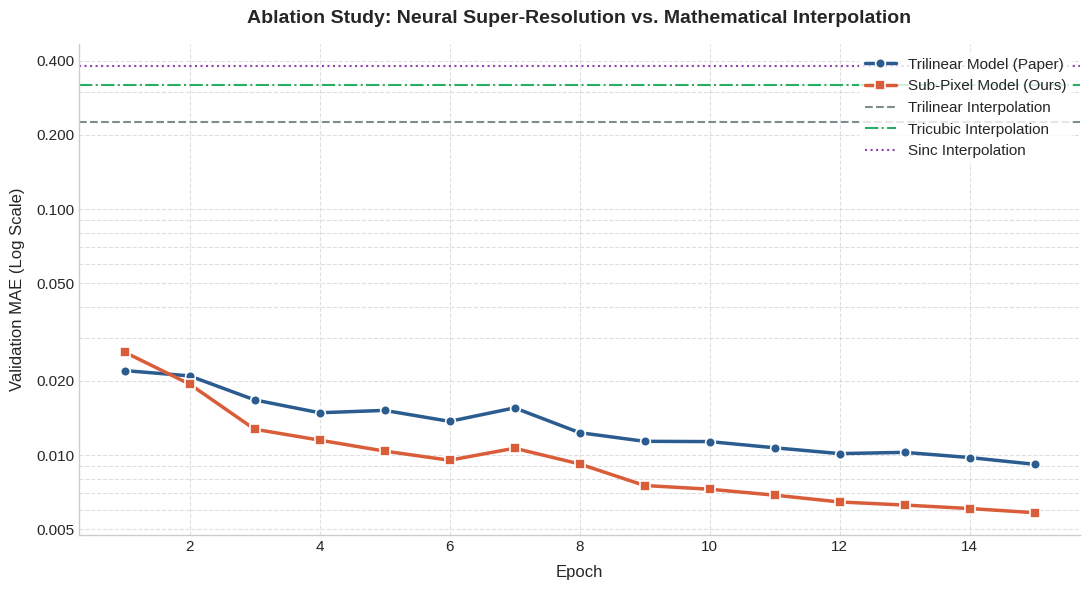

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(11, 6), dpi=100)
ax = plt.gca()

# Remove top and right spines for a clean paper look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

epochs = range(1, len(trilinear_history) + 1)

# Style model convergence lines
plt.plot(epochs, [h['mae'] for h in trilinear_history],
         label='Trilinear Model (Paper)', color='#2B5C8F', linewidth=2.5,
         marker='o', markersize=7, markeredgecolor='white', markeredgewidth=1.2)
plt.plot(epochs, [h['mae'] for h in subpixel_no_icnr_history],
         label='Sub-Pixel Model (Ours)', color='#D95D39', linewidth=2.5,
         marker='s', markersize=7, markeredgecolor='white', markeredgewidth=1.2)

# Style mathematical baseline lines
plt.axhline(y=t_final['tri_mae'], color='#7F8C8D', linestyle='--', linewidth=1.5,
            label='Trilinear Interpolation')
plt.axhline(y=t_final['cub_mae'], color='#27AE60', linestyle='-.', linewidth=1.5,
            label='Tricubic Interpolation')
plt.axhline(y=t_final['sinc_mae'], color='#8E44AD', linestyle=':', linewidth=1.5,
            label='Sinc Interpolation')

# Titles and labels
plt.title('Ablation Study: Neural Super-Resolution vs. Mathematical Interpolation',
          fontsize=14, fontweight='semibold', pad=15)
plt.xlabel('Epoch', fontsize=12, labelpad=8)
plt.ylabel('Validation MAE (Log Scale)', fontsize=12, labelpad=8)

# Apply log scale to y-axis to handle the massive dynamic range
plt.yscale('log')

# Format ticks with clean scalar values instead of scientific notation
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter()) # Clean up minor ticks
ax.set_yticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4])

# Configure the grid (enable 'both' to handle log gridlines cleanly)
plt.grid(True, which='both', linestyle='--', alpha=0.5, color='#BDC3C7')

# Legend and ticks
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.show()


## 6. Paper-Style Visual Comparison and 3D Flow Reconstruction

Recreate the paper-style visual table for one fixed synthetic patch: LR, HR, trilinear interpolation, cubic interpolation, sinc interpolation, the paper-style trilinear 4DFlowNet, and the PixelShuffle candidate. The first three rows show velocity components; the fourth row shows masked divergence inside the fluid domain. This is the visual artifact check that MAE alone cannot provide.


In [ ]:
def slice_2d(volume, z=None):
    if z is None:
        z = volume.shape[-3] // 2
    return volume[..., z, :, :]


def masked_divergence_3d(v, mask_threshold=0.03):
    if v.ndim == 4:
        v = v.unsqueeze(0)

    div = divergence(v).squeeze(0).detach().cpu()
    speed = torch.linalg.vector_norm(v.squeeze(0).detach().cpu(), dim=0)
    mask = speed[1:-1, 1:-1, 1:-1] > mask_threshold
    return div.masked_fill(~mask, float("nan"))


@torch.no_grad()
def make_2d_ablation_visual(seed=999, save_name="2d_ablation_visual.png"):
    ds = SyntheticFlowDataset(samples=1, use_kspace_noise=True, seed=seed)
    lr, hr = ds[0]
    lr_batch = lr.unsqueeze(0).to(device)

    trilinear_interp = upsample_lr(
        lr_batch,
        hr.shape[-1],
        mode="trilinear",
    ).squeeze(0).cpu()

    pred_trilinear = trilinear_model(lr_batch).squeeze(0).cpu()
    pred_subpixel = subpixel_no_icnr_model(lr_batch).squeeze(0).cpu()
    pred_subpixel_icnr = subpixel_icnr_model(lr_batch).squeeze(0).cpu()

    columns = [
        ("LR", lr[:3]),
        ("HR", hr),
        ("Trilinear\ninterp", trilinear_interp),
        ("4DFlowNet\ntrilinear", pred_trilinear),
        ("4DFlowNet\nPixelShuffle", pred_subpixel),
        ("4DFlowNet\nPixelShuffle+ICNR", pred_subpixel_icnr),
    ]

    row_labels = [
        "$V_x$\n(cm/s)",
        "$V_y$\n(cm/s)",
        "$V_z$\n(cm/s)",
        "divergence\n(1/s)",
    ]

    venc_cm_s = 100.0
    fig, axes = plt.subplots(4, len(columns), figsize=(14, 8), dpi=180)
    plt.subplots_adjust(wspace=0.03, hspace=0.06)

    velocity_limits = []
    for component in range(3):
        values = torch.cat([
            volume[component].reshape(-1)
            for _, volume in columns[1:]
        ]) * venc_cm_s
        limit = torch.quantile(values.abs(), 0.995).item()
        velocity_limits.append(max(limit, 1.0))

    div_values = []
    for _, volume in columns[1:]:
        div = masked_divergence_3d(volume)
        finite = div[torch.isfinite(div)]
        if finite.numel() > 0:
            div_values.append(torch.quantile(finite.abs(), 0.98).item())

    div_limit = max(div_values + [1e-3])

    for col_idx, (title, volume) in enumerate(columns):
        for row_idx in range(4):
            ax = axes[row_idx, col_idx]
            ax.set_xticks([])
            ax.set_yticks([])

            if row_idx == 0:
                ax.set_title(title, fontsize=9, pad=4)

            if col_idx == 0:
                ax.set_ylabel(
                    row_labels[row_idx],
                    fontsize=9,
                    rotation=0,
                    labelpad=30,
                    va="center",
                )

            if row_idx < 3:
                image = slice_2d(volume[row_idx]) * venc_cm_s
                limit = velocity_limits[row_idx]
                im = ax.imshow(
                    image,
                    cmap="RdBu_r",
                    vmin=-limit,
                    vmax=limit,
                    interpolation="nearest",
                )
            else:
                image = slice_2d(masked_divergence_3d(volume))
                im = ax.imshow(
                    image,
                    cmap="RdBu_r",
                    vmin=-div_limit,
                    vmax=div_limit,
                    interpolation="nearest",
                )

            if col_idx == len(columns) - 1:
                cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
                cbar.ax.tick_params(labelsize=6, length=2)

    fig.suptitle(
        "2D ablation visual: trilinear interpolation vs 4DFlowNet upsampling variants",
        fontsize=12,
        y=0.98,
    )

    out_path = FIGURE_DIR / save_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    print(f"saved: {out_path}")

    return fig


fig = make_2d_ablation_visual()
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

def axis_size(volume, component):
    # volume shape: [3, D, H, W]
    _, D, H, W = volume.shape
    return [D, H, W][component]

def velocity_slice_at_fraction(volume, component, frac):
    _, D, H, W = volume.shape

    if component == 0:
        idx = int(round(frac * (D - 1)))
        return volume[0, idx, :, :]

    if component == 1:
        idx = int(round(frac * (H - 1)))
        return volume[1, :, idx, :]

    if component == 2:
        idx = int(round(frac * (W - 1)))
        return volume[2, :, :, idx]

    raise ValueError(component)

def scalar_slice_at_fraction(field, component, frac):
    # field shape: [D, H, W]
    D, H, W = field.shape

    if component == 0:
        idx = int(round(frac * (D - 1)))
        return field[idx, :, :]

    if component == 1:
        idx = int(round(frac * (H - 1)))
        return field[:, idx, :]

    if component == 2:
        idx = int(round(frac * (W - 1)))
        return field[:, :, idx]

    raise ValueError(component)

def scalar_slice_at(field, component, idx):
    # field shape: [D, H, W]
    D, H, W = field.shape

    if component == 0:
        idx = min(max(int(idx), 0), D - 1)
        return field[idx, :, :]

    if component == 1:
        idx = min(max(int(idx), 0), H - 1)
        return field[:, idx, :]

    if component == 2:
        idx = min(max(int(idx), 0), W - 1)
        return field[:, :, idx]

    raise ValueError(f"unknown component: {component}")

def edge_score_2d(img):
    img = img.float()
    dx = img[:, 1:] - img[:, :-1]
    dy = img[1:, :] - img[:-1, :]
    return dx.abs().mean() + dy.abs().mean()

def strongest_slice_index(hr, component, margin=2):
    # Pick from HR speed magnitude so the selected slice tends to contain vessel walls.
    # Reuse this index for every method in the table.
    speed = torch.linalg.vector_norm(hr, dim=0)  # [D, H, W]
    D, H, W = speed.shape
    axis_size_val = [D, H, W][component]

    lo = min(margin, axis_size_val - 1)
    hi = max(lo + 1, axis_size_val - margin)

    best_idx = lo
    best_score = -float("inf")

    for idx in range(lo, hi):
        img = scalar_slice_at(speed, component, idx)
        score = float(edge_score_2d(img).item())

        if score > best_score:
            best_score = score
            best_idx = idx

    return best_idx, best_score

def divergence_volume(volume, mask_threshold=0.03):
    # volume shape: [3, D, H, W]
    v = volume.unsqueeze(0)
    div = divergence(v).squeeze(0).detach().cpu()

    speed = torch.linalg.vector_norm(volume.detach().cpu(), dim=0)
    mask = speed[1:-1, 1:-1, 1:-1] > mask_threshold

    return div.masked_fill(~mask, float("nan"))

def finite_minmax(images, fallback=(-1.0, 1.0)):
    values = []

    for img in images:
        flat = img.reshape(-1)
        flat = flat[torch.isfinite(flat)]
        if flat.numel() > 0:
            values.append(flat)

    if not values:
        return fallback

    values = torch.cat(values)
    vmin = float(values.min().item())
    vmax = float(values.max().item())

    if abs(vmax - vmin) < 1e-8:
        pad = max(abs(vmax), 1.0) * 0.05
        vmin -= pad
        vmax += pad

    return vmin, vmax

def fluid_mask_from_hr(hr, threshold=1e-4):
    speed = torch.linalg.vector_norm(hr, dim=0)
    return speed > threshold

@torch.no_grad()
def make_2d_ablation_table(seed=999, sample_idx=3, save_name="2d_ablation_table.png"):
    ds = SyntheticFlowDataset(samples=max(sample_idx + 1, 4), use_kspace_noise=True, seed=seed)
    lr, hr = ds[sample_idx]

    lr = lr.cpu()
    hr = hr.cpu()
    lr_batch = lr.unsqueeze(0).to(device)

    trilinear_model.eval()
    subpixel_no_icnr_model.eval()
    subpixel_icnr_model.eval()

    linear = upsample_lr(lr_batch, hr.shape[-1], mode="trilinear").squeeze(0).cpu()
    pred_trilinear = trilinear_model(lr_batch).squeeze(0).cpu()
    pred_pixelshuffle = subpixel_no_icnr_model(lr_batch).squeeze(0).cpu()
    pred_pixelshuffle_icnr = subpixel_icnr_model(lr_batch).squeeze(0).cpu()
    
    # Slice and mask predicted volumes based on ground truth
    # to keep error/divergence metrics clean outside vessel boundary
    mask = fluid_mask_from_hr(hr)
    pred_trilinear = pred_trilinear * mask
    pred_pixelshuffle = pred_pixelshuffle * mask
    pred_pixelshuffle_icnr = pred_pixelshuffle_icnr * mask

    columns = [
        ("LR", lr[:3]),
        ("HR", hr),
        ("Linear", linear),
        ("4DFlowNet\ntrilinear", pred_trilinear),
        ("4DFlowNet\nPixelShuffle", pred_pixelshuffle),
        ("4DFlowNet\nPixelShuffle+ICNR", pred_pixelshuffle_icnr),
    ]

    venc_cm_s = 100.0

    best_indices = {}
    for component in range(3):
        idx, score = strongest_slice_index(hr, component, margin=2)
        best_indices[component] = idx
        print(f"component {component}: slice={idx}, edge_score={score:.5f}")

    best_fractions = {}

    for component in range(3):
        idx, score = strongest_slice_index(hr, component, margin=2)
        size = axis_size(hr, component)
        frac = idx / (size - 1)

        best_indices[component] = idx
        best_fractions[component] = frac

        print(f"component {component}: HR slice={idx}, frac={frac:.3f}, edge_score={score:.5f}")

    image_grid = []

    for component in range(3):
        idx = best_indices[component]
        row = []
        for _, volume in columns:
            frac = best_fractions[component]
            row.append(velocity_slice_at_fraction(volume, component, frac) * venc_cm_s)
        image_grid.append(row)


    div_row = []
    div_frac = best_fractions[2]  # use the same relative slice as the Vz/W-oriented row

    for _, volume in columns:
        div = divergence_volume(volume)
        div_row.append(scalar_slice_at_fraction(div, component=2, frac=div_frac))

    image_grid.append(div_row)

    error_row = []
    for name, volume in columns:
        if name == "LR" or name == "HR":
            # Black reference square for LR/HR because error to HR is not meaningful there.
            error_row.append(torch.zeros_like(scalar_slice_at(hr[0], 2, best_indices[2])))
        else:
            speed_error = torch.linalg.vector_norm(volume - hr, dim=0) * venc_cm_s
            error_row.append(scalar_slice_at(speed_error, 2, best_indices[2]))

    image_grid.append(error_row)

    row_ranges = [finite_minmax(row) for row in image_grid]

    row_labels = [
        "$V_x$\n(cm/s)",
        "$V_y$\n(cm/s)",
        "$V_z$\n(cm/s)",
        "divergence\n(1/s)",
        "velocity\nerror\n(cm/s)",
    ]

    n_rows = 5
    n_cols = len(columns)

    fig = plt.figure(figsize=(11, 8.4), dpi=220)

    gs = gridspec.GridSpec(
        n_rows,
        n_cols + 1,
        width_ratios=[1] * n_cols + [0.035],
        wspace=0.0,
        hspace=0.0,
        left=0.075,
        right=0.965,
        top=0.92,
        bottom=0.06,
    )

    axes = [[fig.add_subplot(gs[r, c]) for c in range(n_cols)] for r in range(n_rows)]
    cbar_axes = [fig.add_subplot(gs[r, n_cols]) for r in range(n_rows)]

    for r in range(n_rows):
        vmin, vmax = row_ranges[r]
        last_im = None

        for c in range(n_cols):
            ax = axes[r][c]
            img = image_grid[r][c]

            if r == n_rows - 2:
                  cmap = "terrain"
            elif r == n_rows - 1:
                  cmap = "gnuplot"
            else:
                cmap = "jet"

            last_im = ax.imshow(
                img,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
                aspect="auto",
            )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.55)
                spine.set_color("#222")
                
            if r == 0:
                ax.set_title(
                    columns[c][0],
                    fontsize=8.5,
                    fontweight="bold",
                    pad=3,
                )
                
            if c == 0:
                ax.set_ylabel(
                    row_labels[r],
                    fontsize=8.5,
                    fontweight="bold",
                    rotation=0,
                    labelpad=30,
                    va="center",
                )

        cbar = fig.colorbar(last_im, cax=cbar_axes[r])
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.outline.set_linewidth(0.5)

    fig.suptitle(
        "2D ablation table: velocity-component slices and divergence",
        fontsize=11,
        fontweight="bold",
        y=0.965,
    )

    out_path = FIGURE_DIR / save_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    print(f"saved: {out_path}")

    return fig

fig = make_2d_ablation_table(seed=999, sample_idx=56)
plt.show()
